# IS 362 Final Project
## Questions:
1. **Which skills (Python, SQL, TensorFlow, PyTorch) pay more?**
2. **How has demand and salary for data analysts changed as AI influence grows?**

## Data Sources:
- **Kaggle CSV** — Global AI Job Market & Salary Trends 2025 (flat file / relational)
- **BLS Public Data API** — Average hourly earnings & employment trends (web API)

---
## Section 1 — Data Acquisition

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import json
from scipy import stats
import kagglehub
import os

print('Libraries loaded successfully')

Libraries loaded successfully


In [56]:
path = kagglehub.dataset_download("bismasajjad/global-ai-job-market-and-salary-trends-2025")
csv_file_path = os.path.join(path, 'ai_job_dataset.csv')
kaggle_df = pd.read_csv(csv_file_path)

print(kaggle_df['job_title'])

Using Colab cache for faster access to the 'global-ai-job-market-and-salary-trends-2025' dataset.
0              AI Research Scientist
1               AI Software Engineer
2                      AI Specialist
3                       NLP Engineer
4                      AI Consultant
                    ...             
14995              Robotics Engineer
14996    Machine Learning Researcher
14997                   NLP Engineer
14998                     Head of AI
14999       Computer Vision Engineer
Name: job_title, Length: 15000, dtype: object


Download and load kaggle dataset. I used the path code that was provided on the kaggle website. Find csv file in downloaded dataset folder.open and read data. Display some information.

In [57]:
API_KEY = 'b9b6dcad879a4978bc6ecd93936884b3'

payload = json.dumps({
    'seriesid': ['CES0500000003', 'CES0500000001'],
    'startyear': '2019',
    'endyear': '2024',
    'annualaverage': True,
    'registrationkey': API_KEY
})

response = requests.post(
    'https://api.bls.gov/publicAPI/v2/timeseries/data/',
    data=payload,
    headers={'Content-type': 'application/json'}
)

bls_raw = json.loads(response.text)
print('BLS Status:', bls_raw['status'])
print('BLS Messages:', bls_raw['message'])

BLS Status: REQUEST_SUCCEEDED
BLS Messages: []


I registered to use the BLS public data api and recieved api key via email. store api key to get access to BLS api. Use JSON format for key-value pairs. Request information from BLS public data api by using unique seriel codes. CES0500000003 for wages, CES0500000001 for total private employment. Check if the API call was successful and contains results.Loop through the BLS API response, pull out the important data points, and organize them into rows so they can be turned into a pandas table.

In [58]:
rows = []
for series in bls_raw['Results']['series']:
    for point in series['data']:
        if point['periodName'] != 'Annual':
            rows.append({
                'series_id': series['seriesID'],
                'year':      int(point['year']),
                'period':    point['periodName'],
                'value':     float(point['value'])
            })

bls_df = pd.DataFrame(rows)
bls_annual = bls_df.groupby(['series_id', 'year'])['value'].mean().reset_index()
bls_annual['period'] = 'Annual'
bls_annual = bls_annual.sort_values(['series_id', 'year']).reset_index(drop=True)

print(f'BLS rows: {len(bls_annual)} (expect ~12: 2 series x 6 years)')
bls_annual

BLS rows: 12 (expect ~12: 2 series x 6 years)


,series_id,year,value,period
0,CES0500000001,2019,128293.250000,Annual
1,CES0500000001,2020,120179.583333,Annual
2,CES0500000001,2021,124317.333333,Annual
3,CES0500000001,2022,130349.500000,Annual
4,CES0500000001,2023,133097.750000,Annual
5,CES0500000001,2024,134325.750000,Annual
6,CES0500000003,2019,27.998333,Annual
7,CES0500000003,2020,29.360000,Annual
8,CES0500000003,2021,30.613333,Annual
9,CES0500000003,2022,32.258333,Annual


Loop through the BLS API response, pull out the important data points, and store in dataframe.

---
## Section 2 — Transformation & Cleaning

In [59]:
print('Null counts:')
print(kaggle_df.isnull().sum())
print('\nSalary stats:')
print(kaggle_df['salary_usd'].describe())

Null counts:
job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

Salary stats:
count     15000.000000
mean     115348.965133
std       60260.940438
min       32519.000000
25%       70179.750000
50%       99705.000000
75%      146408.500000
max      399095.000000
Name: salary_usd, dtype: float64


Show how many missing values (blank or empty entries) each column has in your dataset. There's 0 missing, so dataset is complete. Show how salaries are distributed in the dataset (averge, minimum, maximum).

In [60]:
kaggle_usd = kaggle_df[kaggle_df['salary_currency'] == 'USD'].copy()
print(f'USD rows: {len(kaggle_usd)} of {len(kaggle_df)} total')

USD rows: 11957 of 15000 total


Filter to USD salaries only

In [61]:
kaggle_usd['posting_date'] = pd.to_datetime(kaggle_usd['posting_date'])
kaggle_usd['post_year'] = kaggle_usd['posting_date'].dt.year

print('posting_date dtype after conversion:', kaggle_usd['posting_date'].dtype)
print('Years present:', sorted(kaggle_usd['post_year'].unique()))

posting_date dtype after conversion: datetime64[ns]
Years present: [np.int32(2024), np.int32(2025)]


Parse posting_date string into datetime, extract year. Convert string column into proper date format.

In [62]:
kaggle_usd['skill_list'] = kaggle_usd['required_skills'].str.split(',')
kaggle_exploded = kaggle_usd.explode('skill_list').copy()
kaggle_exploded['skill_list'] = kaggle_exploded['skill_list'].str.strip().str.lower()

print('Top 30 skills in dataset:')
print(kaggle_exploded['skill_list'].value_counts().head(30))

Top 30 skills in dataset:
skill_list
python                3542
sql                   2733
tensorflow            2453
kubernetes            2398
pytorch               2231
scala                 2206
linux                 2179
git                   2111
java                  2077
gcp                   1949
hadoop                1919
tableau               1862
r                     1821
computer vision       1819
data visualization    1813
deep learning         1758
mlops                 1738
azure                 1726
nlp                   1692
spark                 1691
aws                   1620
mathematics           1525
docker                1463
statistics            1444
Name: count, dtype: int64


Expand skills from wide to long.
Each row has comma-separated skills. Split and explode so each skill gets its own row

In [63]:
analyst_mask = kaggle_usd['job_title'].str.contains(
    'Data Analyst|Data Scientist|ML Engineer|Machine Learning|AI Engineer|Data Engineer',
    case=False, na=False
)
analyst_df = kaggle_usd[analyst_mask].copy()

print(f'Analyst-related roles: {len(analyst_df)} rows')
print(analyst_df['job_title'].value_counts().head(10))

Analyst-related roles: 3621 rows
job_title
Machine Learning Researcher    652
Machine Learning Engineer      617
Data Analyst                   600
Data Engineer                  592
Principal Data Scientist       580
Data Scientist                 580
Name: count, dtype: int64


Filter Kaggle to data analyst / AI roles only

In [64]:
bls_annual['date'] = pd.to_datetime(bls_annual['year'], format='%Y')

print('BLS date dtype:', bls_annual['date'].dtype)
bls_annual.head()

BLS date dtype: datetime64[ns]


,series_id,year,value,period,date
0,CES0500000001,2019,128293.250000,Annual,2019-01-01
1,CES0500000001,2020,120179.583333,Annual,2020-01-01
2,CES0500000001,2021,124317.333333,Annual,2021-01-01
3,CES0500000001,2022,130349.500000,Annual,2022-01-01
4,CES0500000001,2023,133097.750000,Annual,2023-01-01


Turn the year number into a proper date format for time-based analysis/plotting.

---
## Section 3 — Exploratory Analysis & Data Validation

In [65]:
print('=== Kaggle USD Salary Stats ===')
print(kaggle_usd['salary_usd'].describe().round(2))

print('\n=== BLS Avg Hourly Earnings Stats ===')
bls_annual['series_id'] = bls_annual['series_id'].str.strip()
bls_wages = bls_annual[bls_annual['series_id'] == 'CES0500000003']
print(bls_wages[['year', 'value']].to_string(index=False))

=== Kaggle USD Salary Stats ===
count     11957.00
mean     113457.15
std       61381.01
min       32519.00
25%       67862.00
50%       96951.00
75%      144518.00
max      399095.00
Name: salary_usd, dtype: float64

=== BLS Avg Hourly Earnings Stats ===
 year     value
 2019 27.998333
 2020 29.360000
 2021 30.613333
 2022 32.258333
 2023 33.695833
 2024 35.057500


statistical analysis that describes/validates data. 1. summary of the salary_usd column (like average, min, max, etc.), and rounds the numbers to 2 decimal places so it looks cleaner.
2. filter the BLS dataset to only keep rows for average hourly earnings (wages)

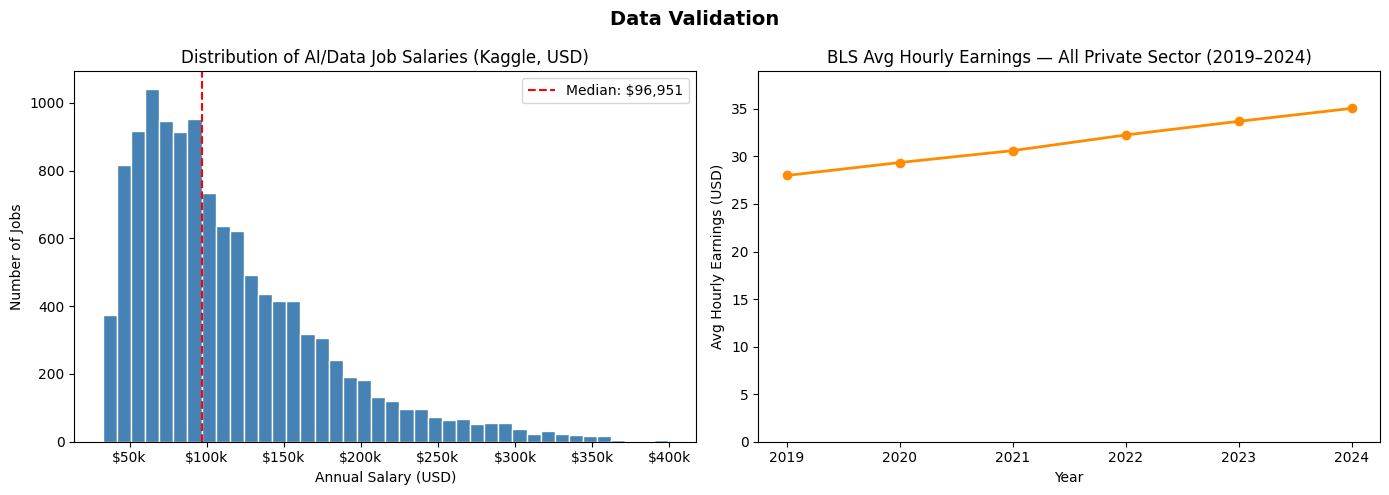

Saved fig1_validation.png


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Validation', fontsize=14, fontweight='bold')

axes[0].hist(kaggle_usd['salary_usd'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(kaggle_usd['salary_usd'].median(), color='red', linestyle='--',
                label=f"Median: ${kaggle_usd['salary_usd'].median():,.0f}")
axes[0].set_title('Distribution of AI/Data Job Salaries (Kaggle, USD)')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Number of Jobs')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

axes[1].plot(bls_wages['year'], bls_wages['value'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('BLS Avg Hourly Earnings — All Private Sector (2019–2024)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Hourly Earnings (USD)')
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.1)

plt.tight_layout()
plt.savefig('fig1_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_validation.png')

create space for graphs to compare Kaggle salary data with BLS wage data. Graph 1 is a histogram of Kaggle AI/data job salaries and marks the median salary with a red dashed line. The right chart shows how average wage from BLS change over time from 2019 to 2024 using a line plot.

---
## Section 4 — Analysis: Which Skills Pay More?

In [67]:
TARGET_SKILLS = ['python', 'sql', 'tensorflow', 'pytorch']

skill_salary = kaggle_exploded[kaggle_exploded['skill_list'].isin(TARGET_SKILLS)].copy()

print(f'Rows with target skills: {len(skill_salary)}')
print(skill_salary['skill_list'].value_counts())

Rows with target skills: 10959
skill_list
python        3542
sql           2733
tensorflow    2453
pytorch       2231
Name: count, dtype: int64


store target skills in variable. Filter  dataset to keep only the rows where those skills appear in the skill_list column. Store filtered data in a new DataFrame called skill_salary. Print how many matching rows there are and shows how often each of those skills appears.

In [68]:
skill_summary = skill_salary.groupby('skill_list')['salary_usd'].agg(
    count='count',
    median='median',
    mean='mean',
    std='std'
).reset_index().sort_values('median', ascending=False)

print('=== Salary by Skill ===')
print(skill_summary.round(2))

=== Salary by Skill ===
   skill_list  count   median       mean       std
1     pytorch   2231  97958.0  113337.69  61353.58
0      python   3542  95634.0  112708.07  61685.85
3  tensorflow   2453  95560.0  113232.57  61885.43
2         sql   2733  94643.0  111185.91  60117.98


Group the data by each skill in skill_list and calculates salary statistics for each one (count, median, mean, standard deviation). Reset the index and sorts the skills from highest to lowest median salary. Print label so output is easy to read. Display the summary table rounded to 2 decimal places.

In [69]:
groups = [
    skill_salary[skill_salary['skill_list'] == s]['salary_usd'].dropna()
    for s in TARGET_SKILLS
]

f_stat, p_value = stats.f_oneway(*groups)
print(f'ANOVA Test: F={f_stat:.2f}, p={p_value:.4f}')
if p_value < 0.05:
    print('→ Salary differences between skills are statistically significant (p < 0.05)')
else:
    print('→ No statistically significant difference found (p >= 0.05)')

ANOVA Test: F=0.68, p=0.5623
→ No statistically significant difference found (p >= 0.05)


Check whether the salary differences between different skills (Python, SQL, TensorFlow, PyTorch) are real or coincidence. Create separate salary groups for each skill from dataset. Run an ANOVA test, which compares the averages of multiple groups at once. Print test results (differences are statistically significant based on the p-value, using 0.05 as the cutoff).

/tmp/ipykernel_4936/2180610965.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=TARGET_SKILLS, patch_artist=True)


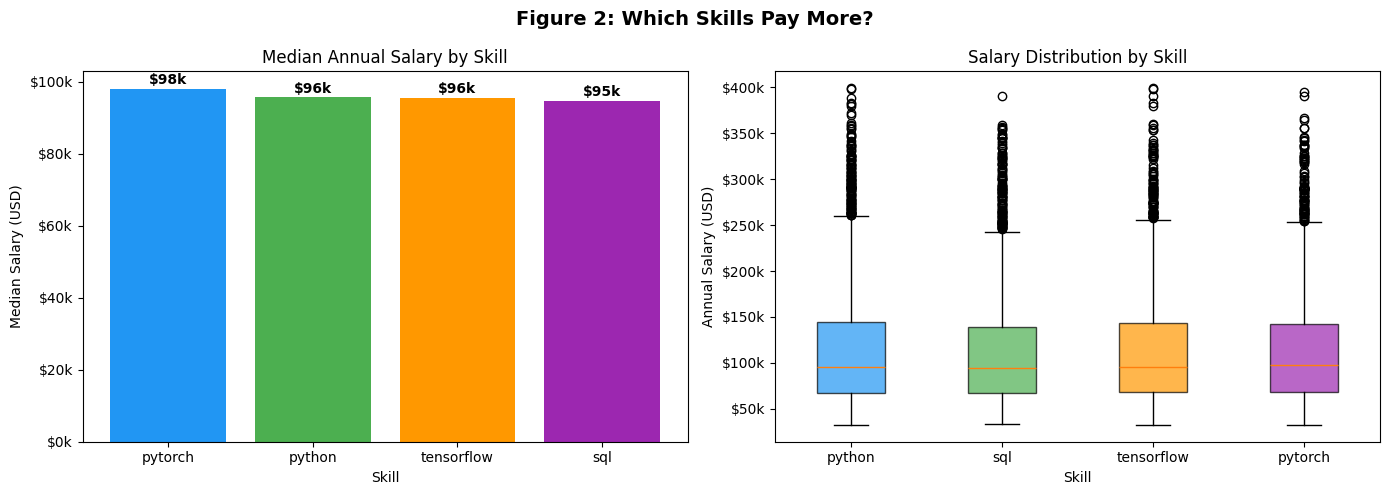

Saved fig2_skill_salary.png


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Which Skills Pay More?', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
skill_summary_sorted = skill_summary.sort_values('median', ascending=False)

bars = axes[0].bar(
    skill_summary_sorted['skill_list'],
    skill_summary_sorted['median'],
    color=colors
)
axes[0].set_title('Median Annual Salary by Skill')
axes[0].set_xlabel('Skill')
axes[0].set_ylabel('Median Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, val in zip(bars, skill_summary_sorted['median']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=10, fontweight='bold')

box_data = [skill_salary[skill_salary['skill_list'] == s]['salary_usd'].dropna() for s in TARGET_SKILLS]
bp = axes[1].boxplot(box_data, labels=TARGET_SKILLS, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Salary Distribution by Skill')
axes[1].set_xlabel('Skill')
axes[1].set_ylabel('Annual Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('fig2_skill_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_skill_salary.png')

Create room for 2 graphs, comparing which skills pay more. The left bar chart was created using median salary values for each skill and then annotated with exact dollar labels on top of each bar for easier comparison. The boxplot on the right was generated from the full salary distributions for each skill, allowing visualization of spread, median, and outliers across different skill groups.

---
## Section 5 — Analysis: How Has Demand & Salary Changed?

In [71]:
analyst_by_year = analyst_df.groupby('post_year')['salary_usd'].agg(
    median_salary='median',
    mean_salary='mean',
    job_count='count'
).reset_index().sort_values('post_year')

print('=== Data Analyst Trend by Year ===')
print(analyst_by_year)

=== Data Analyst Trend by Year ===
   post_year  median_salary    mean_salary  job_count
0       2024        95568.0  111279.532025       2701
1       2025       100214.0  115387.508696        920


Group Data Analyst jobs by the year they were posted and calculate summary salary statistics for each year. Computesthe median salary, average salary, and number of jobs for every post_year. Reset the index and sort the results in chronological order. Print a clean table showing how Data Analyst salaries and job counts change over time.

In [72]:
exp_summary = analyst_df.groupby('experience_level')['salary_usd'].agg(
    count='count',
    median='median'
).reset_index().sort_values('median', ascending=False)

print(exp_summary)

entry = analyst_df[analyst_df['experience_level'] == 'EN']['salary_usd']
senior = analyst_df[analyst_df['experience_level'] == 'SE']['salary_usd']
t_stat, p_val = stats.ttest_ind(entry, senior)
print(f'\nT-test (Entry vs Senior): t={t_stat:.2f}, p={p_val:.4f}')

  experience_level  count    median
1               EX    892  170063.5
3               SE    911  110498.0
2               MI    884   79450.0
0               EN    934   56933.5

T-test (Entry vs Senior): t=-41.60, p=0.0000


Compare Data Analyst salaries across different experience levels ( entry-level vs senior). Group the data by experience level and calculates how many jobs there are and the median salary for each group. Compare entry-level and senior-level salaries using a t-test. Print whether the salary difference between these two groups is statistically significant.

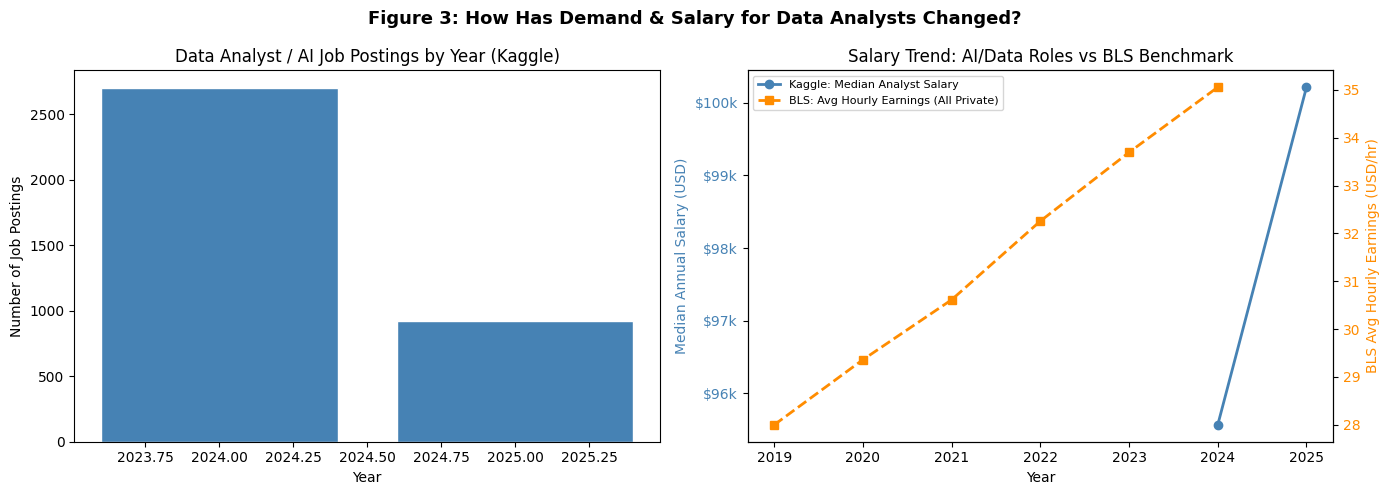

Saved fig3_analyst_trend.png


In [73]:
bls_wages = bls_annual[bls_annual['series_id'] == 'CES0500000003'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3: How Has Demand & Salary for Data Analysts Changed?',
             fontsize=13, fontweight='bold')

axes[0].bar(analyst_by_year['post_year'], analyst_by_year['job_count'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Data Analyst / AI Job Postings by Year (Kaggle)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Job Postings')

ax_left = axes[1]
ax_right = axes[1].twinx()

ax_left.plot(analyst_by_year['post_year'], analyst_by_year['median_salary'],
             marker='o', color='steelblue', linewidth=2, label='Kaggle: Median Analyst Salary')
ax_left.set_ylabel('Median Annual Salary (USD)', color='steelblue')
ax_left.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax_left.tick_params(axis='y', labelcolor='steelblue')

ax_right.plot(bls_wages['year'], bls_wages['value'],
              marker='s', linestyle='--', color='darkorange', linewidth=2,
              label='BLS: Avg Hourly Earnings (All Private)')
ax_right.set_ylabel('BLS Avg Hourly Earnings (USD/hr)', color='darkorange')
ax_right.tick_params(axis='y', labelcolor='darkorange')

axes[1].set_title('Salary Trend: AI/Data Roles vs BLS Benchmark')
axes[1].set_xlabel('Year')

lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_analyst_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_analyst_trend.png')

Filter BLS dataset to keep only average hourly earnings data (wages), and make a safe copy of it. Create space for charts. Create a bar chart showing how many analyst jobs were posted each year. Create plot chart based on how median Data Analyst salary changes over time.Plot average hourly earnings for all private workers for comparison. Collect legend info from both axes so they can be shown together.

---
## Section 6 — Conclusions

In [74]:
print('\nQ1 — Which skills pay more?')
for _, row in skill_summary.iterrows():
    print(f"  {row['skill_list'].upper():<15} Median: ${row['median']:>9,.0f}   (n={int(row['count'])}")
print(f'  ANOVA p={p_value:.4f} — {"significant" if p_value < 0.05 else "not significant"} difference')

print('\nQ2 — How has demand/salary for data analysts changed?')
for _, row in analyst_by_year.iterrows():
    print(f"  {int(row['post_year'])}: {int(row['job_count'])} postings, "
          f"median salary ${row['median_salary']:,.0f}")
if len(analyst_by_year) > 2:
    print(f'  Pearson r={corr:.3f}, p={p_corr:.4f}')


Q1 — Which skills pay more?
  PYTORCH         Median: $   97,958   (n=2231
  PYTHON          Median: $   95,634   (n=3542
  TENSORFLOW      Median: $   95,560   (n=2453
  SQL             Median: $   94,643   (n=2733
  ANOVA p=0.5623 — not significant difference

Q2 — How has demand/salary for data analysts changed?
  2024: 2701 postings, median salary $95,568
  2025: 920 postings, median salary $100,214


Loop through each row in skill_summary table (each skill one by one), and print info. Print the ANOVA test result which indicates whether salary differences between skills are statistically significant. Loop through each year of analyst data. Print yearly summary showing number of job postings, and median salary for that year. Check if there is enough data to do a trend analysis. Print the correlation result showing how strongly salary changes over time (r) and whether it is statistically significant (p-value).